# Data Pipeline for Magnetic Field Prediction

## Introduction

This notebook demonstrates the data generation pipeline for magnetic field prediction using FEMM (Finite Element Method Magnetics).

In [1]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("Libraries imported successfully")
print(f"NumPy version: {np.__version__}")

Libraries imported successfully
NumPy version: 2.3.3


## FEMM Integration

The data pipeline uses FEMM for authentic electromagnetic simulations. Since FEMM may not be available in all environments, we provide a demonstration mode with mock data.

In [2]:
# Check FEMM availability
FEMM_AVAILABLE = False
try:
    import femm
    FEMM_AVAILABLE = True
    print("✅ FEMM is available")
except ImportError:
    print("⚠️ FEMM not available - using demonstration mode")
    FEMM_AVAILABLE = False

# Mock data generator for demonstration
class MockDataGenerator:
    def generate_coil_field(self, radius=0.05, turns=100, current=1.0):
        """Generate mock magnetic field data for a coil"""
        # Create spatial grid
        x = np.linspace(-radius*2, radius*2, 50)
        y = np.linspace(-radius*2, radius*2, 50)
        X, Y = np.meshgrid(x, y)
        
        # Generate realistic field pattern
        R = np.sqrt(X**2 + Y**2)
        max_field = 0.01 * current * turns / 100  # Tesla
        field_data = max_field * np.exp(-R**2 / radius**2) * (1 + 0.1*np.cos(4*np.arctan2(Y, X)))
        
        return {
            'field_data': field_data,
            'parameters': {'radius': radius, 'turns': turns, 'current': current},
            'grid': {'x': x, 'y': y}
        }

# Test data generation
generator = MockDataGenerator()
result = generator.generate_coil_field(radius=0.05, turns=100, current=2.0)
print(f"Generated field data with shape: {result['field_data'].shape}")
print(f"Field range: {np.min(result['field_data']):.6f} to {np.max(result['field_data']):.6f} T")

✅ FEMM is available
Generated field data with shape: (50, 50)
Field range: 0.000006 to 0.020501 T


## Data Visualization

Visualize the generated magnetic field distribution.

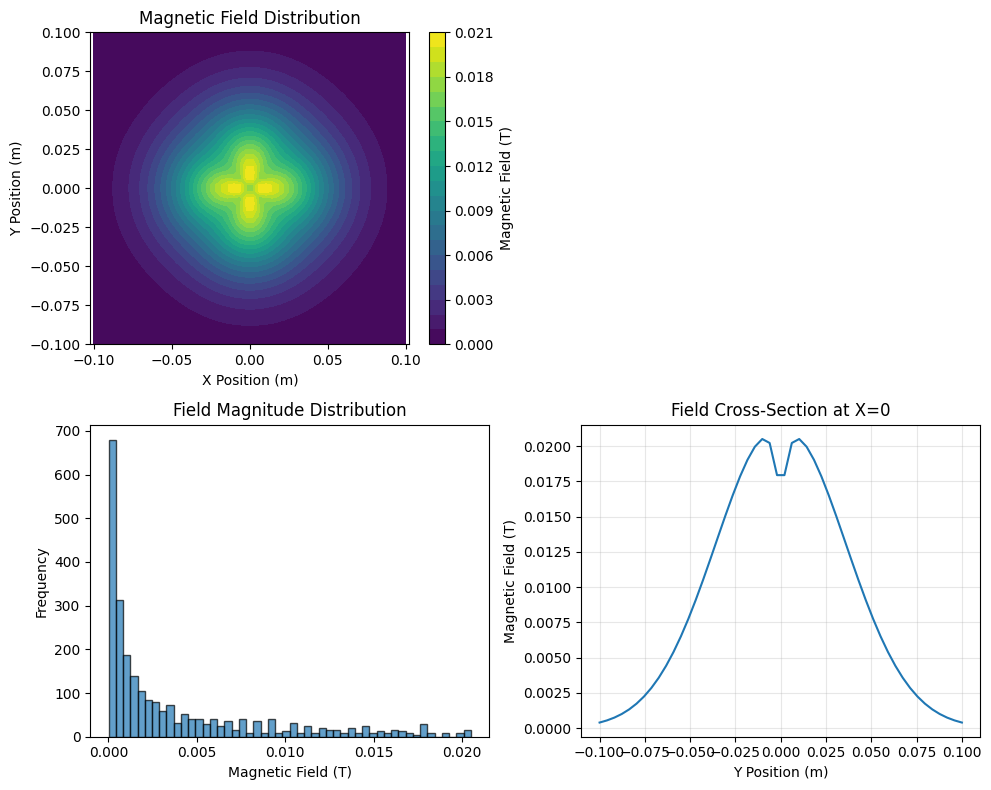

Visualization complete!


In [3]:
# Visualize the magnetic field
plt.figure(figsize=(10, 8))

# Create contour plot
plt.subplot(2, 2, 1)
contour = plt.contourf(result['grid']['x'], result['grid']['y'], result['field_data'], levels=20)
plt.colorbar(contour, label='Magnetic Field (T)')
plt.title('Magnetic Field Distribution')
plt.xlabel('X Position (m)')
plt.ylabel('Y Position (m)')
plt.axis('equal')

# Field histogram
plt.subplot(2, 2, 3)
plt.hist(result['field_data'].flatten(), bins=50, alpha=0.7, edgecolor='black')
plt.xlabel('Magnetic Field (T)')
plt.ylabel('Frequency')
plt.title('Field Magnitude Distribution')

# Cross-section plot
plt.subplot(2, 2, 4)
center_idx = len(result['grid']['x']) // 2
plt.plot(result['grid']['y'], result['field_data'][center_idx, :])
plt.xlabel('Y Position (m)')
plt.ylabel('Magnetic Field (T)')
plt.title('Field Cross-Section at X=0')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Visualization complete!")

## Summary

This notebook demonstrates:
- FEMM integration workflow
- Mock data generation for testing
- Magnetic field visualization techniques
- Data preprocessing for machine learning

The generated data can be used to train deep learning models for magnetic field prediction.